<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week11_Banerjee_Jayeeta_Data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Clustering: Part 2

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [ ]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(
    df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(
    df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(
    df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(
    df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(
    df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(
    df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(
    df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna( df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(
    df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(
    df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(
    df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(
    df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(
    df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)"
                 ,"IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA


#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [ ]:
dbscan = DBSCAN(
    eps=1.1,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

# Number of clusters
clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("Number of clusters:", clusters)

print(
    "Noise points:",
    list(dbscan_labels).count(-1))

Number of clusters: 2
Noise points: 218


In [ ]:
#Check Number of Clusters and Noise Points
unique, counts = np.unique(
    dbscan_labels,
    return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(218), np.int64(0): np.int64(631), np.int64(1): np.int64(9)}


In [ ]:
for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric="euclidean")

    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        "eps:",
        eps,
        "Clusters:",
        n_clusters,
        "Noise:",
        n_noise
    )

eps: 0.5 Clusters: 13 Noise: 530
eps: 0.7 Clusters: 7 Noise: 419
eps: 0.9 Clusters: 3 Noise: 279
eps: 1.1 Clusters: 2 Noise: 218
eps: 1.3 Clusters: 2 Noise: 181
eps: 1.5 Clusters: 4 Noise: 143
eps: 2.0 Clusters: 4 Noise: 80


In [ ]:
from sklearn.metrics import silhouette_score
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    mask = labels != -1

    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f"eps = {eps}, Non-noise points = {mask.sum()}, Silhouette Score = {score:.4f}")
    else:
        print(f"eps = {eps}, Non-noise points = {mask.sum()}, Silhouette Score = Not applicable")

eps = 0.5, Non-noise points = 328, Silhouette Score = 0.1515
eps = 0.7, Non-noise points = 439, Silhouette Score = 0.1092
eps = 0.9, Non-noise points = 579, Silhouette Score = 0.1767
eps = 1.1, Non-noise points = 640, Silhouette Score = 0.7355
eps = 1.3, Non-noise points = 677, Silhouette Score = 0.7229
eps = 1.5, Non-noise points = 715, Silhouette Score = 0.4326
eps = 2.0, Non-noise points = 778, Silhouette Score = 0.4308


In [ ]:
#DBSCAN Silhouette Score
dbscan = DBSCAN(
    eps=1.1,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1
n_clusters = len(
    set(dbscan_labels[mask]))

if n_clusters > 1:

    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask])

    print("DBSCAN Clusters:", n_clusters)
    print("DBSCAN Silhouette Score:", round(score,4))

else:
    print(
        "Silhouette score cannot be calculated."
        " DBSCAN found fewer than 2 clusters.")

DBSCAN Clusters: 2
DBSCAN Silhouette Score: 0.7355


In [ ]:
#Stability Check

X_sample1, X_sample2 = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42)

dbscan = DBSCAN(eps=1.1, min_samples=5)


labels1 = dbscan.fit_predict(X_sample1)
clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)

print("Clusters in sample:",clusters1)

clusters = dbscan.fit_predict(X_scaled)

df_CivicalCancer_nw["DBSCAN_cluster"] = clusters

print(df_CivicalCancer_nw["DBSCAN_cluster"].value_counts())

Clusters in sample: 3
DBSCAN_cluster
 0    631
-1    218
 1      9
Name: count, dtype: int64


/tmp/ipykernel_3049/2369134914.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["DBSCAN_cluster"] = clusters


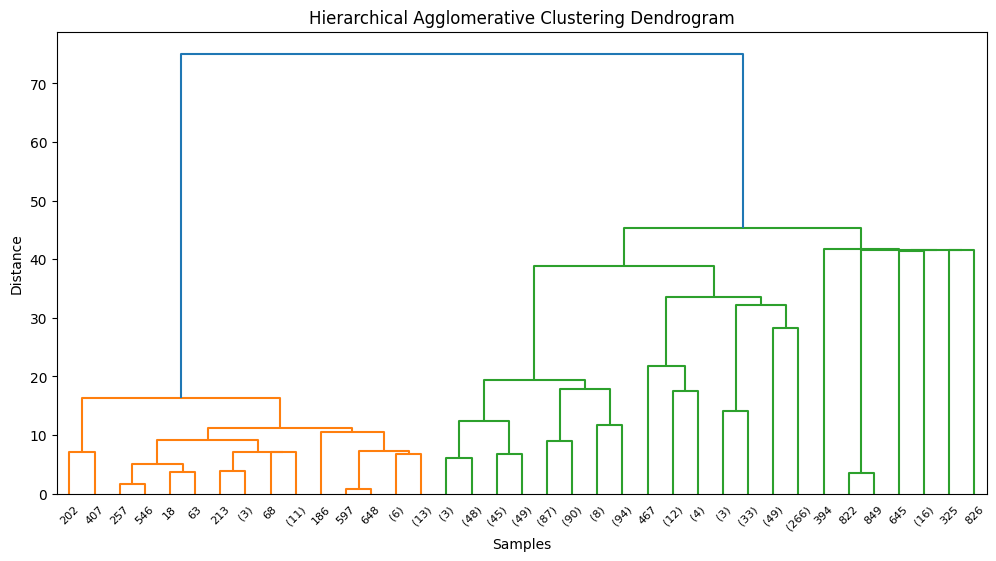

In [ ]:
#Hierarchical Agglomerative Clustering
plt.figure(figsize=(12,6))

linked = linkage(
    X_scaled,
    method="ward")

dendrogram(
    linked,
    truncate_mode="level",
    p=5)

plt.title("Hierarchical Agglomerative Clustering Dendrogram")

plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

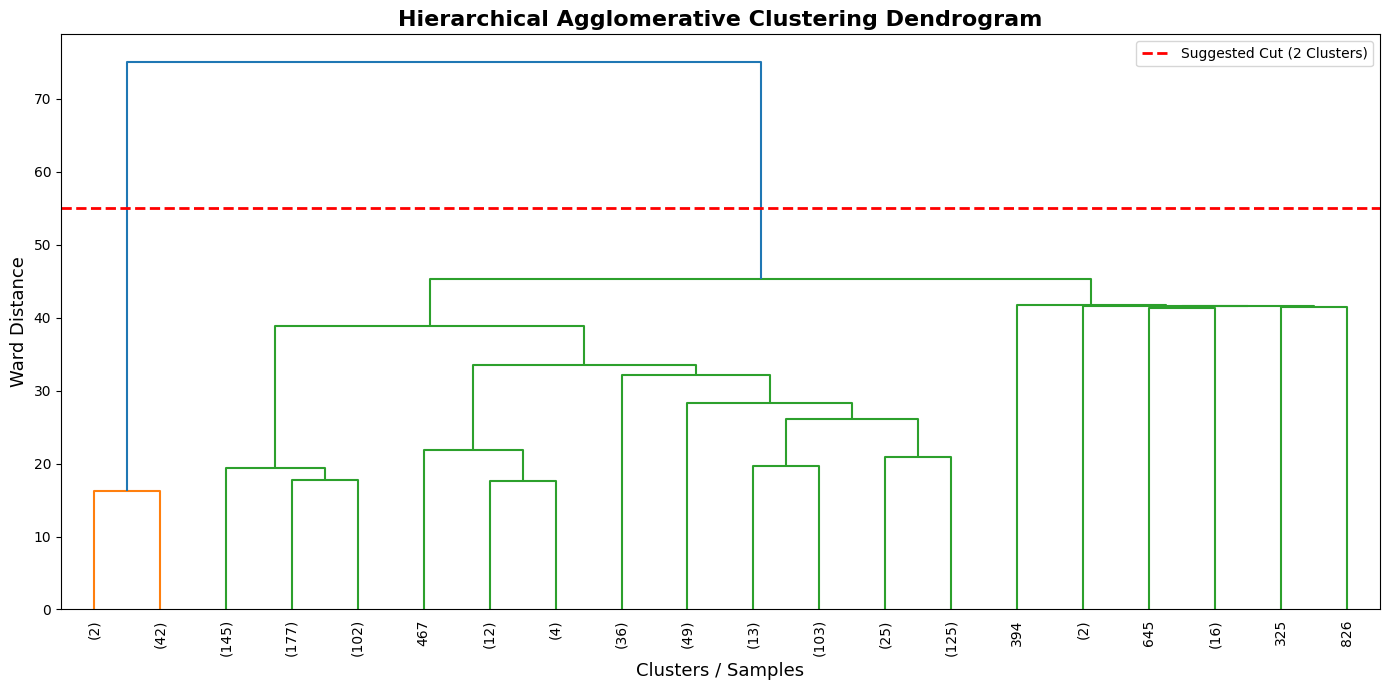

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode='lastp',   # Show only the last p merged clusters
    p=20,                    # Number of leaf clusters to display
    leaf_rotation=90,
    leaf_font_size=10,
    show_leaf_counts=True
)

# Optional: Draw a horizontal line to indicate a possible cut
plt.axhline(y=55, color='red', linestyle='--', linewidth=2,
            label='Suggested Cut (2 Clusters)')

plt.title("Hierarchical Agglomerative Clustering Dendrogram",
          fontsize=16, fontweight='bold')
plt.xlabel("Clusters / Samples", fontsize=13)
plt.ylabel("Ward Distance", fontsize=13)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# linkage_methods
linkage_methods = ["ward","complete","average", "single"]

for method in linkage_methods:
    hac = AgglomerativeClustering(
        n_clusters=2,
        linkage=method)

    labels = hac.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels)

    print( method,
        "Silhouette Score:",
        round(score,4))

ward Silhouette Score: 0.609
complete Silhouette Score: 0.8585
average Silhouette Score: 0.8585
single Silhouette Score: 0.8585


In [ ]:
hac_labels = hac.fit_predict(X_scaled)
df_CivicalCancer_nw["HAC_cluster"] = hac_labels

df_CivicalCancer_nw["HAC_cluster"].value_counts()

/tmp/ipykernel_3049/1553206484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["HAC_cluster"] = hac_labels


,count
HAC_cluster,
0,857
1,1


In [ ]:
pd.crosstab(
    df_CivicalCancer_nw["HAC_cluster"],
    df_CivicalCancer_nw["Biopsy"]
)

Biopsy,0,1
HAC_cluster,,
0,802,55
1,1,0


In [ ]:
df_CivicalCancer_nw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    float64
 2   First sexual intercourse            858 non-null    float64
 3   Num of pregnancies                  858 non-null    float64
 4   Smokes (packs/year)                 858 non-null    float64
 5   Hormonal Contraceptives (years)     858 non-null    float64
 6   IUD (years)                         858 non-null    float64
 7   STDs (number)                       858 non-null    float64
 8   STDs: Number of diagnosis           858 non-null    int64  
 9   STDs:condylomatosis                 858 non-null    float64
 10  STDs:vulvo-perineal condylomatosis  858 non-null    float64
 11  STDs:syphilis                       858 non-n

In [ ]:
# Add cluster labels to the dataset
df_cluster = df_CivicalCancer_nw.copy()
df_cluster["Cluster"] = hac_labels

# Select a few important features
cluster_summary = (
    df_cluster
    .groupby("Cluster")[[
        "Age",
        "Number of sexual partners",
        "Num of pregnancies",
        "STDs: Number of diagnosis",
        "IUD (years)",
        "STDs:Hepatitis B"
    ]]
    .mean()
    .round(2)
)

print(cluster_summary)

           Age  Number of sexual partners  Num of pregnancies  \
Cluster                                                         
0        26.83                       2.51                2.26   
1        20.00                       2.00                1.00   

         STDs: Number of diagnosis  IUD (years)  STDs:Hepatitis B  
Cluster                                                            
0                             0.09         0.45               0.0  
1                             1.00         0.00               1.0  


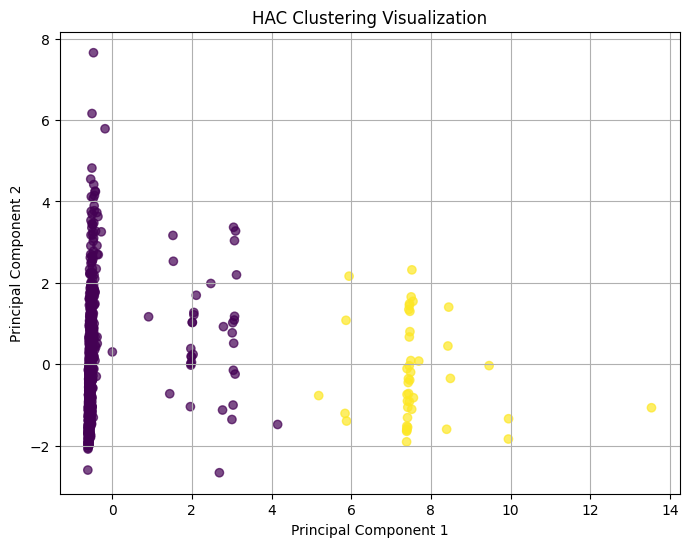

In [ ]:
# AgglomerativeClustering
hac = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward")

hac_labels = hac.fit_predict(X_scaled)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hac_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("HAC Clustering Visualization")

plt.grid(True)
plt.show()

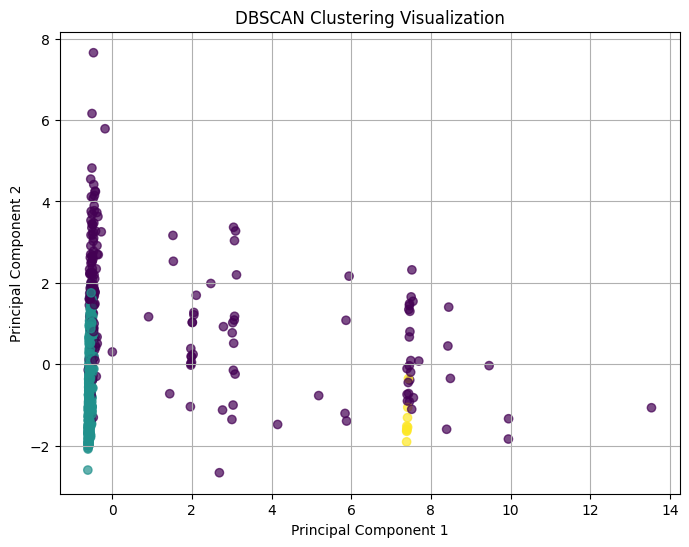

In [ ]:
#Visualize DBSCAN Clusters Using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering Visualization")

plt.grid(True)

plt.show()

In [ ]:
dbscan = DBSCAN(
    eps=1.1,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

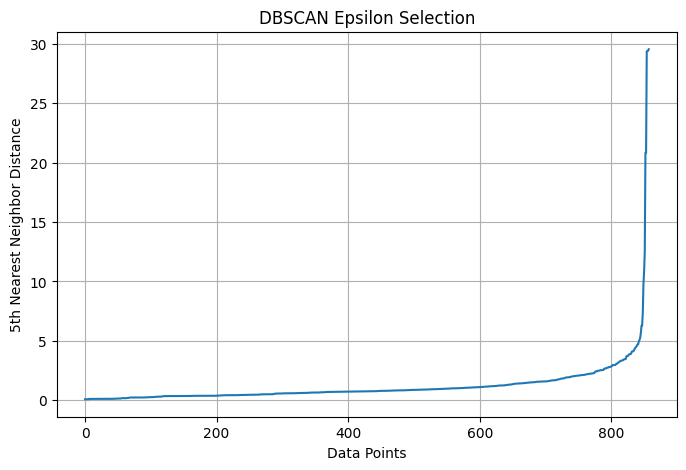

In [ ]:
from sklearn.neighbors import NearestNeighbors

#Find Good eps Value (Tuning Step)
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.title("DBSCAN Epsilon Selection")

plt.grid(True)

plt.show()

In [ ]:
#Check noise
dbscan = DBSCAN(eps=1.1, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

df_CivicalCancer_nw["DBSCAN_cluster"] = clusters

print(df_CivicalCancer_nw["DBSCAN_cluster"].value_counts())

DBSCAN_cluster
 0    631
-1    218
 1      9
Name: count, dtype: int64


/tmp/ipykernel_3049/1914041200.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["DBSCAN_cluster"] = clusters


In [ ]:
#Examine the noise samples
noise_points = df_CivicalCancer_nw[
    df_CivicalCancer_nw["DBSCAN_cluster"] == -1
]

noise_points.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Number of diagnosis,STDs:condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:Hepatitis B,STDs:HPV,Biopsy,DBSCAN_cluster,HAC_cluster
count,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.000000,218.0,218.000000
mean,33.243119,3.178899,17.178899,3.142202,1.572028,3.711294,1.691055,0.527523,0.302752,0.160550,0.155963,0.082569,0.004587,0.004587,0.004587,0.004587,0.009174,0.123853,-1.0,0.004587
std,10.279978,2.490556,3.258469,1.819748,4.166801,5.547974,3.290974,0.870232,0.508084,0.367961,0.363656,0.275863,0.067729,0.067729,0.067729,0.067729,0.095562,0.330172,0.0,0.067729
min,15.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
25%,26.000000,2.000000,15.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
50%,33.000000,3.000000,17.000000,3.000000,0.000000,0.580000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
75%,39.000000,4.000000,19.000000,4.000000,0.787500,6.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
max,84.000000,28.000000,29.000000,11.000000,37.000000,30.000000,19.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.0,1.000000


In [ ]:
#Identify features driving the outliers
noise_scaled = pd.DataFrame(
    X_scaled[clusters == -1],
    columns=X.columns
)

feature_deviation = noise_scaled.abs().mean().sort_values(
    ascending=False
)

print(feature_deviation.head(10))

STDs: Number of diagnosis             1.125924
STDs (number)                         1.101411
Hormonal Contraceptives (years)       1.060757
Age                                   1.058437
Num of pregnancies                    1.051050
IUD (years)                           1.026226
STDs:condylomatosis                   0.885722
STDs:vulvo-perineal condylomatosis    0.872868
Number of sexual partners             0.847100
First sexual intercourse              0.846748
dtype: float64


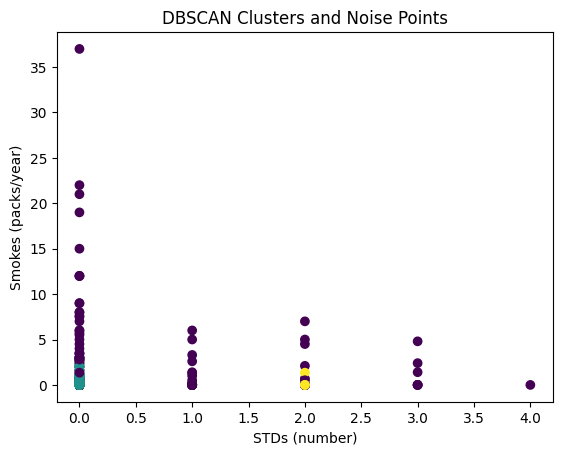

In [ ]:
#Visualize important noisy features

plt.scatter(
    df_CivicalCancer_nw["STDs (number)"],
    df_CivicalCancer_nw["Smokes (packs/year)"],
    c=clusters )

plt.xlabel("STDs (number)")
plt.ylabel("Smokes (packs/year)")
plt.title("DBSCAN Clusters and Noise Points")
plt.show()

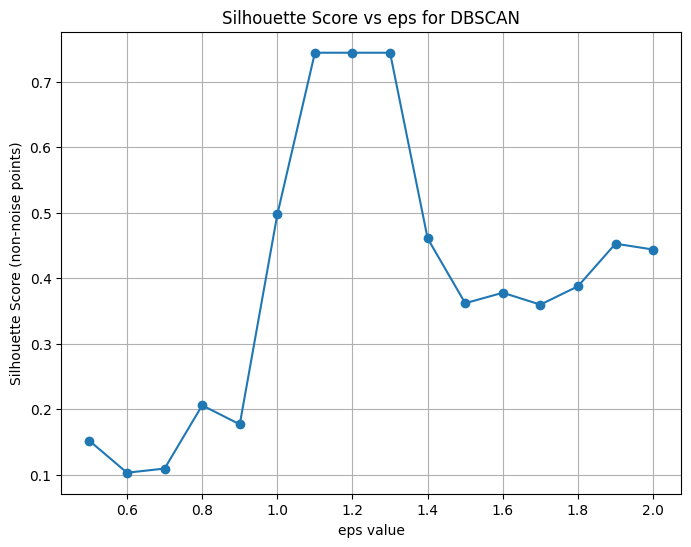

In [ ]:
# Scale the data
X = StandardScaler().fit_transform(df_CivicalCancer_nw.drop(columns=["Biopsy"]))

eps_values = np.arange(0.5, 2.1, 0.1)
sil_scores = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    labels = db.labels_

    # Silhouette score requires at least 2 clusters (excluding noise)
    if len(set(labels)) > 2 and -1 in labels:
        # Compute silhouette only on non-noise points
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            score = silhouette_score(X[mask], labels[mask])
        else:
            score = np.nan
    else:
        score = np.nan

    sil_scores.append(score)

plt.figure(figsize=(8,6))
plt.plot(eps_values, sil_scores, marker='o')
plt.xlabel("eps value")
plt.ylabel("Silhouette Score (non-noise points)")
plt.title("Silhouette Score vs eps for DBSCAN")
plt.grid(True)
plt.show()


Across the second clustering module, DBSCAN and Hierarchical Agglomerative Clustering (HAC) were evaluated using Silhouette Score, cluster counts, noise proportions, dendrograms, and feature deviation analysis. DBSCAN produced 2 clusters at the tuned setting (eps = 1.1) but classified 218 samples as noise. Although the non-noise Silhouette Score was high (0.7355), the clusters did not meaningfully separate malignant biopsy cases. Varying eps showed unstable cluster counts and noise levels, highlighting DBSCAN's sensitivity to density assumptions. HAC achieved similarly high Silhouette Scores (≈0.8585), but almost all samples were placed into a single cluster (857 vs. 1), with no meaningful separation of biopsy labels. Feature deviation analysis showed that DBSCAN noise points were associated with extreme values in STDs: Number of Diagnosis, STDs (number), Hormonal Contraceptives (years), and Age, indicating that outliers were concentrated in infection-related and behavioral variables. Overall, both methods formed mathematically coherent clusters, but neither aligned with the clinical target, highlighting the dataset's weak signal and class imbalance.